# 21 News Classification using Word2Vec

In [3]:
import pandas as pd

df = pd.read_csv("Fake_Real_Data.csv")
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [5]:
df.shape

(9900, 2)

In [6]:
df.label.value_counts()

,count
label,
Fake,5000
Real,4900


In [7]:
df['label_num'] = df.label.map({
    "Fake": 0,
    "Real": 1
})

df.head()

,Text,label,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0
1,U.S. conservative leader optimistic of common ...,Real,1
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0
4,Democrats say Trump agrees to work on immigrat...,Real,1


In [10]:
import spacy
import spacy.cli
spacy.cli.download("en_core_web_lg")
nlp = spacy.load("en_core_web_lg")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [11]:
doc = nlp("Top Trump Surrogate BRUTALLY Stabs Him")
doc.vector.shape

(300,)

In [12]:
df['vector'] = df.Text.apply(lambda x: nlp(x).vector)

In [13]:
df.head()

,Text,label,label_num,vector
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0,"[-0.103623025, 0.17802684, -0.11873861, -0.034..."
1,U.S. conservative leader optimistic of common ...,Real,1,"[-0.0063406364, 0.16712041, -0.06661373, 0.017..."
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1,"[-0.122753024, 0.17192385, -0.024732638, -0.06..."
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0,"[-0.027337318, 0.12501417, -0.0073965387, -0.0..."
4,Democrats say Trump agrees to work on immigrat...,Real,1,"[-0.032708026, 0.093958504, -0.03287002, -0.00..."


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size=0.2,
    random_state=42,
    stratify=df.label_num
)


In [20]:
X_train[0].shape

(300,)

In [24]:
import numpy as np

X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

In [30]:
X_train_2d[0]

array([-9.36961100e-02,  1.62019983e-01, -2.66385246e-02, -4.73496616e-02,
        3.22714006e-03, -4.69200201e-02, -1.90373138e-02, -5.59605472e-02,
        2.70280857e-02,  2.24627447e+00, -2.59696692e-01,  6.60678446e-02,
        3.85159850e-02,  1.63787825e-03, -1.40209362e-01, -3.05753872e-02,
       -5.34886345e-02,  9.79047298e-01, -9.95482504e-02,  1.35113783e-02,
        5.72609948e-04,  2.27189064e-02,  6.96998369e-03, -5.55778369e-02,
       -2.12004147e-02, -2.05197395e-03, -1.52308628e-01, -1.41538503e-02,
       -3.81713249e-02, -1.04370965e-02, -7.07029775e-02,  9.98272747e-02,
       -5.34558669e-03,  7.04901293e-03,  1.05371840e-01, -4.79081199e-02,
       -5.10045700e-02,  8.07106588e-03, -6.93866387e-02, -1.91865265e-02,
        2.91412305e-02,  1.10899366e-01,  5.58014512e-02, -7.85624608e-02,
       -4.66834428e-03,  2.54535004e-02, -4.53785211e-02, -5.17014936e-02,
        6.99978322e-03,  2.46178638e-02, -4.85524870e-02,  4.89438586e-02,
       -2.65182424e-02,  

In [29]:
X_train[0]

array([-9.36961100e-02,  1.62019983e-01, -2.66385246e-02, -4.73496616e-02,
        3.22714006e-03, -4.69200201e-02, -1.90373138e-02, -5.59605472e-02,
        2.70280857e-02,  2.24627447e+00, -2.59696692e-01,  6.60678446e-02,
        3.85159850e-02,  1.63787825e-03, -1.40209362e-01, -3.05753872e-02,
       -5.34886345e-02,  9.79047298e-01, -9.95482504e-02,  1.35113783e-02,
        5.72609948e-04,  2.27189064e-02,  6.96998369e-03, -5.55778369e-02,
       -2.12004147e-02, -2.05197395e-03, -1.52308628e-01, -1.41538503e-02,
       -3.81713249e-02, -1.04370965e-02, -7.07029775e-02,  9.98272747e-02,
       -5.34558669e-03,  7.04901293e-03,  1.05371840e-01, -4.79081199e-02,
       -5.10045700e-02,  8.07106588e-03, -6.93866387e-02, -1.91865265e-02,
        2.91412305e-02,  1.10899366e-01,  5.58014512e-02, -7.85624608e-02,
       -4.66834428e-03,  2.54535004e-02, -4.53785211e-02, -5.17014936e-02,
        6.99978322e-03,  2.46178638e-02, -4.85524870e-02,  4.89438586e-02,
       -2.65182424e-02,  

In [32]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

scaler = MinMaxScaler()
scaled_train_embed = scaler.fit_transform(X_train_2d)

clf = MultinomialNB()
clf.fit(scaled_train_embed, y_train)

MultinomialNB()

In [33]:
from sklearn.metrics import classification_report

X_test_2d_scaled = scaler.transform(X_test_2d)
y_pred = clf.predict(X_test_2d_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1000
           1       0.96      0.93      0.94       980

    accuracy                           0.94      1980
   macro avg       0.94      0.94      0.94      1980
weighted avg       0.94      0.94      0.94      1980



In [34]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
clf.fit(scaled_train_embed, y_train)

y_pred = clf.predict(X_test_2d_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1000
           1       0.97      0.99      0.98       980

    accuracy                           0.98      1980
   macro avg       0.98      0.98      0.98      1980
weighted avg       0.98      0.98      0.98      1980



In TF-IDF and BoW, KNN does not work well due to the high dimensions. Luckily KNN work excellent in word embeddings

# Exercise

In [36]:
import pandas as pd

df = pd.read_json("news_dataset.json")

print(df.shape)

df.head()

(12695, 2)


,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
2,Entrepreneurs Today Don't Need a Big Budget to...,BUSINESS
3,These Roads Could Recharge Your Electric Car A...,BUSINESS
4,Civilian 'Guard' Fires Gun While 'Protecting' ...,CRIME


In [37]:
df.category.value_counts()

,count
category,
BUSINESS,4254
SPORTS,4167
CRIME,2893
SCIENCE,1381


In [38]:
# undersampling
min_sample = 1381

df_business = df[df.category == "BUSINESS"].sample(min_sample, random_state=42)
df_sports = df[df.category == "SPORTS"].sample(min_sample, random_state=42)
df_crime = df[df.category == "CRIME"].sample(min_sample, random_state=42)
df_science = df[df.category == "SCIENCE"].sample(min_sample, random_state=42)


In [39]:
df_final = pd.concat([df_business, df_sports, df_crime, df_science])
df_final.category.value_counts()

,count
category,
BUSINESS,1381
SPORTS,1381
CRIME,1381
SCIENCE,1381


In [41]:
df_final['label_num'] = df_final.category.map({
    "BUSINESS": 0,
    "SPORTS": 1,
    "CRIME": 2,
    "SCIENCE": 3
})
df_final.label_num.value_counts()

,count
label_num,
0,1381
1,1381
2,1381
3,1381


In [42]:
df_final.head()

,text,category,label_num
594,How to Develop the Next Generation of Innovato...,BUSINESS,0
3093,"Madoff Victims' Payout Nears $7.2 Billion, Tru...",BUSINESS,0
7447,Bay Area Floats 'Sanctuary In Transit Policy' ...,BUSINESS,0
10388,Microsoft Agrees To Acquire LinkedIn For $26.2...,BUSINESS,0
1782,"Inside A Legal, Multibillion Dollar Weed Market",BUSINESS,0


In [45]:
# Preprocess function
def preprocess(text):
  doc = nlp(text)
  filtered_tokens = []
  for token in doc:
    if token.is_stop or token.is_punct:
      continue
    filtered_tokens.append(token.lemma_)
  return ' '.join(filtered_tokens)

In [46]:
df_final['preprocessed_text'] = df_final.text.apply(preprocess)

In [47]:
df_final.head()

,text,category,label_num,preprocessed_text
594,How to Develop the Next Generation of Innovato...,BUSINESS,0,develop Generation Innovators stop treat Way g...
3093,"Madoff Victims' Payout Nears $7.2 Billion, Tru...",BUSINESS,0,Madoff Victims Payout near $ 7.2 billion trust...
7447,Bay Area Floats 'Sanctuary In Transit Policy' ...,BUSINESS,0,Bay Area float Sanctuary Transit Policy protec...
10388,Microsoft Agrees To Acquire LinkedIn For $26.2...,BUSINESS,0,Microsoft agree acquire linkedin $ 26.2 billio...
1782,"Inside A Legal, Multibillion Dollar Weed Market",BUSINESS,0,inside Legal Multibillion Dollar Weed market


In [48]:
df_final['vector'] = df_final.preprocessed_text.apply(lambda text: nlp(text).vector)

In [53]:
df_final.head()

,text,category,label_num,preprocessed_text,vector
594,How to Develop the Next Generation of Innovato...,BUSINESS,0,develop Generation Innovators stop treat Way g...,"[-0.13324368, 0.1378314, -0.08942279, 0.038220..."
3093,"Madoff Victims' Payout Nears $7.2 Billion, Tru...",BUSINESS,0,Madoff Victims Payout near $ 7.2 billion trust...,"[-0.34448567, 0.25872177, -0.005446997, -0.065..."
7447,Bay Area Floats 'Sanctuary In Transit Policy' ...,BUSINESS,0,Bay Area float Sanctuary Transit Policy protec...,"[0.049051013, -0.12456093, -0.08001897, -0.037..."
10388,Microsoft Agrees To Acquire LinkedIn For $26.2...,BUSINESS,0,Microsoft agree acquire linkedin $ 26.2 billio...,"[-0.26673564, 0.103503466, -0.038085457, -0.12..."
1782,"Inside A Legal, Multibillion Dollar Weed Market",BUSINESS,0,inside Legal Multibillion Dollar Weed market,"[-0.17266166, -0.055355, 0.23440568, -0.032763..."


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_final.vector,
    df_final.label_num,
    test_size=0.2,
    random_state=42,
    stratify=df_final.label_num
)

In [64]:
print(X_train.shape)
print(type(X_train))
X_train

(4419,)
<class 'pandas.core.series.Series'>


,vector
6414,"[-0.18463011, 0.012435809, 0.05241406, -0.0199..."
1318,"[0.13088523, 0.05396235, -0.004057347, -0.0214..."
4170,"[-0.010504252, 0.15402626, -0.017309625, -0.11..."
11310,"[-0.26921797, 0.297757, -0.105118975, -0.10195..."
4188,"[0.18215913, -0.19176745, -0.041899223, -0.202..."
...,...
8454,"[-0.13347825, 0.030917121, 0.034278505, 0.0241..."
8868,"[-0.035550274, 0.08261507, 0.12772018, 0.08024..."
3206,"[0.008190957, 0.044646453, -0.09496818, 0.0555..."
192,"[-0.155015, 0.031163603, -0.21080402, -0.01489..."


In [65]:
import numpy as np

X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

In [66]:
X_train_2d

array([[-0.18463011,  0.01243581,  0.05241406, ...,  0.04753252,
         0.02176906,  0.003291  ],
       [ 0.13088523,  0.05396235, -0.00405735, ...,  0.14805618,
        -0.01726635,  0.24155521],
       [-0.01050425,  0.15402626, -0.01730962, ..., -0.03147347,
        -0.12572388, -0.014935  ],
       ...,
       [ 0.00819096,  0.04464645, -0.09496818, ..., -0.18241002,
        -0.12487148,  0.18813866],
       [-0.155015  ,  0.0311636 , -0.21080402, ...,  0.2101948 ,
         0.05290391,  0.02322901],
       [-0.5051458 ,  0.1821925 , -0.2049925 , ...,  0.10686925,
        -0.15149751, -0.0368325 ]], dtype=float32)

In [67]:
type(X_train_2d)

numpy.ndarray

In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier()

dt.fit(X_train_2d, y_train)

y_pred = dt.predict(X_test_2d)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.61      0.59       276
           1       0.65      0.67      0.66       276
           2       0.72      0.71      0.71       277
           3       0.68      0.63      0.65       276

    accuracy                           0.65      1105
   macro avg       0.66      0.65      0.65      1105
weighted avg       0.66      0.65      0.65      1105



In [73]:
from sklearn.naive_bayes import MultinomialNB

scaler = MinMaxScaler()
train_embedded = scaler.fit_transform(X_train_2d)
test_embedded = scaler.transform(X_test_2d)

nb = MultinomialNB()
nb.fit(train_embedded, y_train)

y_pred = nb.predict(test_embedded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       276
           1       0.85      0.84      0.85       276
           2       0.90      0.87      0.88       277
           3       0.86      0.83      0.85       276

    accuracy                           0.85      1105
   macro avg       0.85      0.85      0.85      1105
weighted avg       0.85      0.85      0.85      1105



In [74]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(train_embedded, y_train)

y_pred = knn.predict(test_embedded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.91      0.82       276
           1       0.91      0.79      0.85       276
           2       0.84      0.93      0.88       277
           3       0.92      0.74      0.82       276

    accuracy                           0.84      1105
   macro avg       0.85      0.84      0.84      1105
weighted avg       0.85      0.84      0.84      1105



In [75]:
from sklearn.ensemble import RandomForestClassifier

rdm = RandomForestClassifier()
rdm.fit(train_embedded, y_train)

y_pred = rdm.predict(test_embedded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       276
           1       0.89      0.85      0.87       276
           2       0.92      0.90      0.91       277
           3       0.85      0.86      0.86       276

    accuracy                           0.87      1105
   macro avg       0.87      0.87      0.87      1105
weighted avg       0.87      0.87      0.87      1105



In [76]:
from sklearn.ensemble import GradientBoostingClassifier

boost = GradientBoostingClassifier()
boost.fit(train_embedded, y_train)

y_pred = boost.predict(test_embedded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       276
           1       0.90      0.88      0.89       276
           2       0.93      0.90      0.92       277
           3       0.86      0.84      0.85       276

    accuracy                           0.88      1105
   macro avg       0.88      0.88      0.88      1105
weighted avg       0.88      0.88      0.88      1105



Text(95.72222222222221, 0.5, 'Truth')

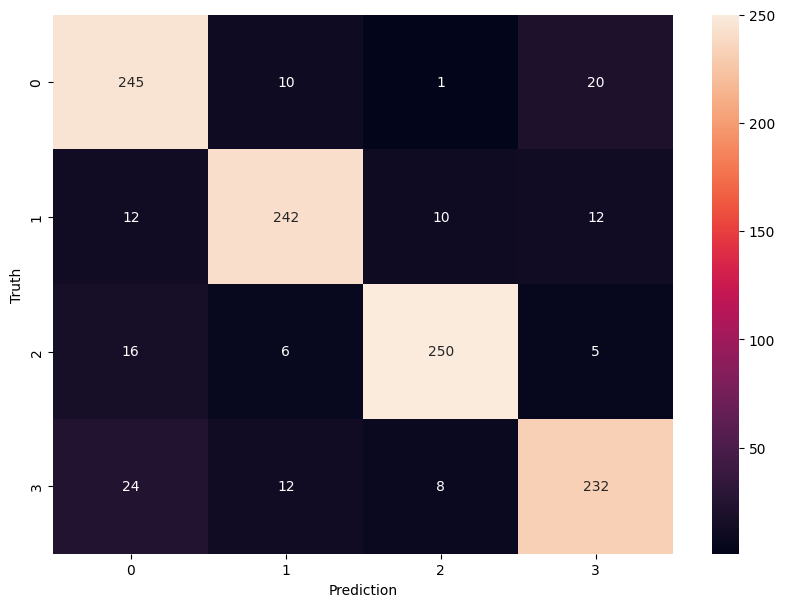

In [81]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm


from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')